In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = sns.load_dataset('titanic')
df = df.dropna(subset=['age', 'fare'])
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()
df.head()

/tmp/ipykernel_584/4233309873.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


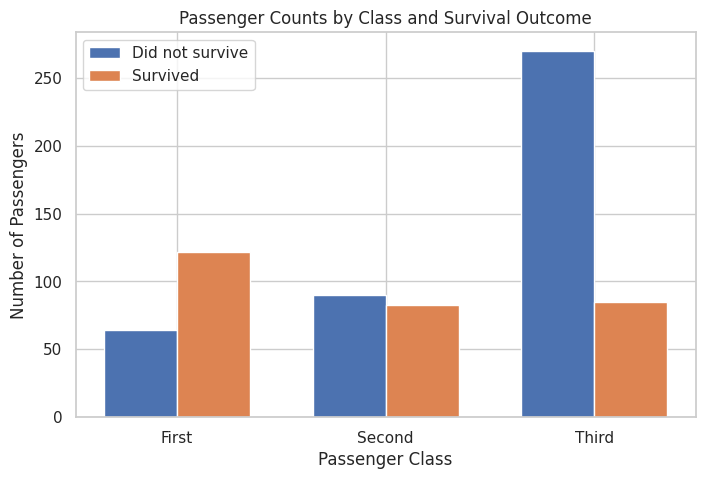

Insight: Third class has the most passengers, with a survival rate of 24%.


In [2]:
counts = df.groupby('class')['survived'].value_counts().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(counts.index))
width = 0.35

ax.bar(x - width/2, counts[0], width, label='Did not survive')
ax.bar(x + width/2, counts[1], width, label='Survived')

ax.set_title('Passenger Counts by Class and Survival Outcome')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Number of Passengers')
ax.set_xticks(x)
ax.set_xticklabels(counts.index)
ax.legend()
plt.show()

top_class = counts.sum(axis=1).idxmax()
survival_rate = counts.loc[top_class, 1] / counts.loc[top_class].sum()
print(f"Insight: {top_class} class has the most passengers, with a survival rate of {survival_rate:.0%}.")

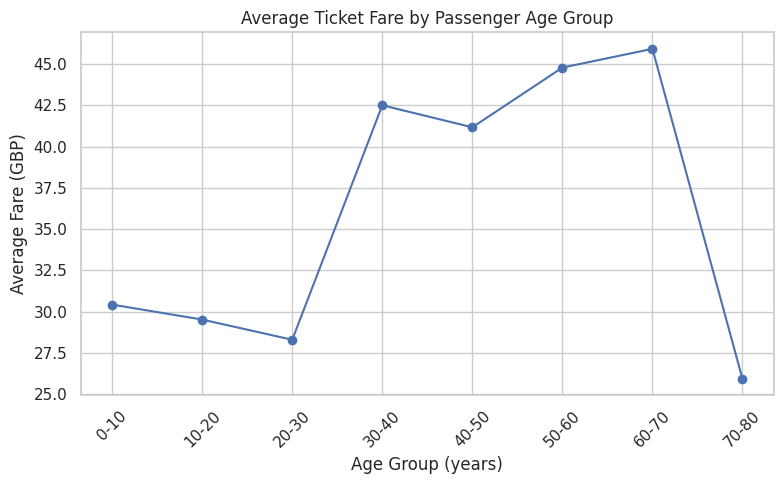

Insight: passengers aged 60-70 paid the highest average fare, around 45.91 GBP.


In [3]:
age_bins = np.arange(0, df['age'].max() + 10, 10)
age_groups = pd.cut(df['age'], bins=age_bins)
avg_fare_by_age = df.groupby(age_groups)['fare'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
x_labels = [f'{int(i.left)}-{int(i.right)}' for i in avg_fare_by_age.index]
ax.plot(x_labels, avg_fare_by_age.values, marker='o')

ax.set_title('Average Ticket Fare by Passenger Age Group')
ax.set_xlabel('Age Group (years)')
ax.set_ylabel('Average Fare (GBP)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

peak_group = avg_fare_by_age.idxmax()
peak_fare = avg_fare_by_age.max()
print(f"Insight: passengers aged {int(peak_group.left)}-{int(peak_group.right)} paid the highest average fare, around {peak_fare:.2f} GBP.")

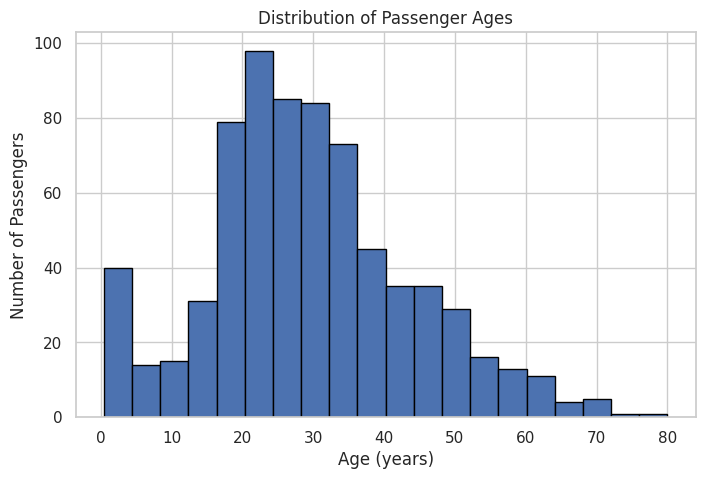

Insight: the distribution is right-skewed, with a median passenger age of 28.0 years.


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['age'], bins=20, edgecolor='black')

ax.set_title('Distribution of Passenger Ages')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Passengers')
plt.show()

median_age = df['age'].median()
print(f"Insight: the distribution is right-skewed, with a median passenger age of {median_age:.1f} years.")

## 4. Scatter Plot (Matplotlib) — Age vs. fare, coloured by survival

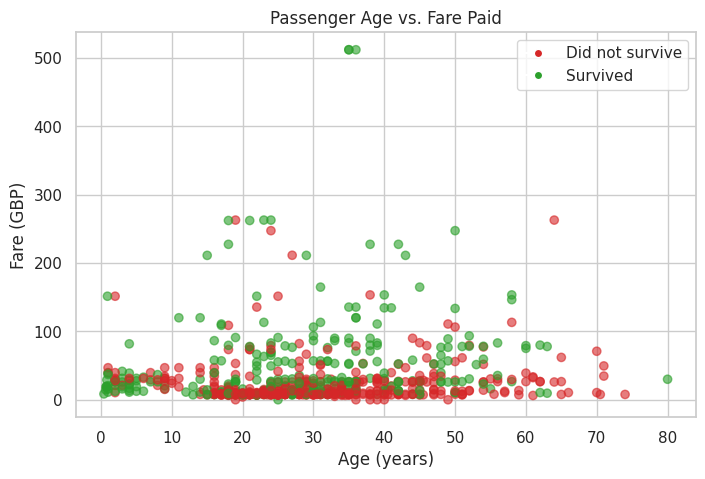

Insight: age and fare show a weak correlation (r = 0.10), so older passengers did not consistently pay more.


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = df['survived'].map({0: 'tab:red', 1: 'tab:green'})
ax.scatter(df['age'], df['fare'], c=colors, alpha=0.6)

ax.set_title('Passenger Age vs. Fare Paid')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (GBP)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l)
           for c, l in zip(['tab:red', 'tab:green'], ['Did not survive', 'Survived'])]
ax.legend(handles=handles)
plt.show()

corr = df['age'].corr(df['fare'])
print(f"Insight: age and fare show a weak correlation (r = {corr:.2f}), so older passengers did not consistently pay more.")

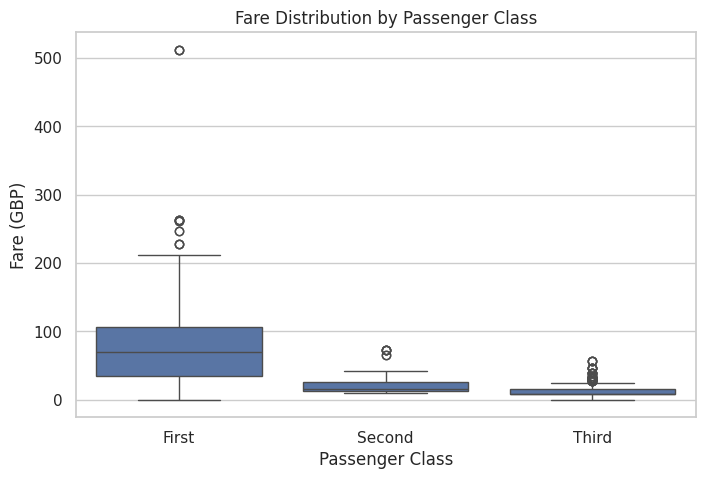

Insight: First class has both the highest median fare and the widest spread of fares, including several high-value outliers.


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='class', y='fare', ax=ax)

ax.set_title('Fare Distribution by Passenger Class')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare (GBP)')
plt.show()

medians = df.groupby('class')['fare'].median()
highest_class = medians.idxmax()
print(f"Insight: {highest_class} class has both the highest median fare and the widest spread of fares, including several high-value outliers.")

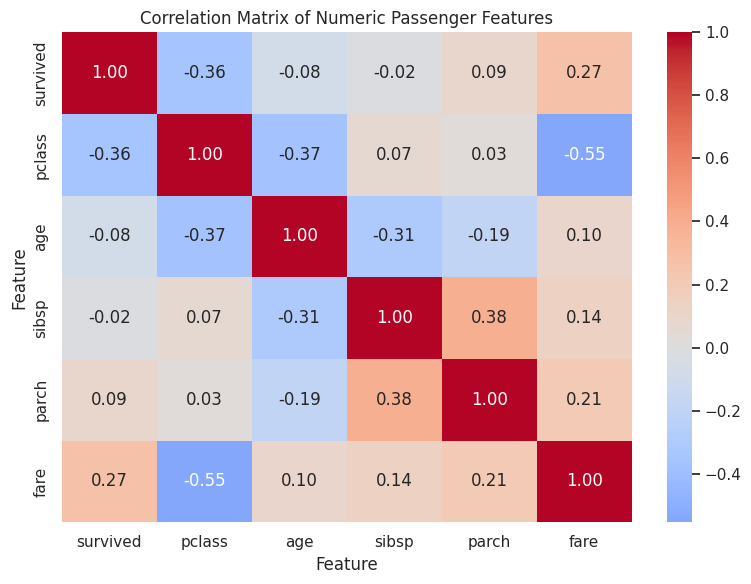

Insight: 'pclass' and 'fare' have the strongest relationship among numeric features (r = -0.55).


In [7]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)

ax.set_title('Correlation Matrix of Numeric Passenger Features')
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

corr_no_diag = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
max_pair = corr_no_diag.abs().stack().idxmax()
max_val = corr_no_diag.loc[max_pair]
print(f"Insight: '{max_pair[0]}' and '{max_pair[1]}' have the strongest relationship among numeric features (r = {max_val:.2f}).")